# Transformer para la detección de puntos de cambio en trayectorias de difusión anómala

Este cuaderno implementa una arquitectura Transformer para estimar la posición del punto de cambio en trayectorias sintéticas de difusión anómala. El protocolo se mantiene igual que en los modelos ConvLSTM, LSTM y ConvTransformer: se carga la base sintética ya generada, se entrena el modelo, se evalúa el error global y se analizan los resultados por transición ordenada entre modelos de difusión.

## 1. Importación de librerías

Se cargan únicamente las librerías necesarias para lectura de datos, entrenamiento del modelo, evaluación y visualización de resultados.

In [1]:
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import layers, models, optimizers, losses, metrics, callbacks

## 2. Configuración experimental

Esta versión está preparada para ejecutar el entrenamiento completo solicitado: `FAST_RUN = False`, 200 000 trayectorias de entrenamiento, 20 000 de validación y 200 000 de prueba. El conjunto de prueba mantiene 10 000 trayectorias por cada transición ordenada entre modelos de difusión.

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

LENGTH = 100
MIN_SEGMENT_LENGTH = 20

MODELS = ["ATTM", "CTRW", "FBM", "LW", "SBM"]
TRANSITIONS = [(m1, m2) for m1 in MODELS for m2 in MODELS if m1 != m2]

FAST_RUN = False
FAST_TRAIN_SIZE = 200000
FAST_VAL_SIZE = 20000
FAST_TEST_SIZE = 200000

EPOCHS = 80
BATCH_SIZE = 256
PREDICT_BATCH_SIZE = 2048

DATA_DIR = Path("C:/Users/chair/Downloads/data_synthetic_changepoint_andi")
OUTPUT_DIR = Path("transformer_results_final")
OUTPUT_DIR.mkdir(exist_ok=True)

## 3. Carga de la base sintética

Cada archivo HDF5 contiene las trayectorias `X`, la posición real del punto de cambio `cp`, los modelos de difusión antes y después del cambio (`model1`, `model2`), los exponentes anómalos y el nivel de ruido. Los identificadores numéricos de los modelos se transforman a sus nombres: `ATTM`, `CTRW`, `FBM`, `LW` y `SBM`.

In [3]:
MODEL_MAP = {
    0: "ATTM",
    1: "CTRW",
    2: "FBM",
    3: "LW",
    4: "SBM"
}


def decode_model_values(values):
    decoded = []
    for value in np.asarray(values).reshape(-1):
        if isinstance(value, np.generic):
            value = value.item()
        if isinstance(value, bytes):
            value = value.decode("utf-8")
        try:
            decoded.append(MODEL_MAP[int(value)])
        except Exception:
            decoded.append(str(value).replace("b'", "").replace("'", "").strip().upper())
    return decoded


def load_split(split_name):
    h5_path = DATA_DIR / f"{split_name}_L100_dim1.h5"

    with h5py.File(h5_path, "r") as file:
        x = file["X"][:].astype("float32")
        positions = file["cp"][:].astype("float32")
        model1 = decode_model_values(file["model1"][:])
        model2 = decode_model_values(file["model2"][:])
        alpha1 = file["alpha1"][:]
        alpha2 = file["alpha2"][:]
        noise_sigma = file["noise_sigma"][:]

    if x.ndim == 2:
        x = x[:, :, None]

    x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)
    y = (positions / LENGTH).astype("float32")

    metadata = pd.DataFrame({
        "cp": positions,
        "model1": model1,
        "model2": model2,
        "alpha1": alpha1,
        "alpha2": alpha2,
        "noise_sigma": noise_sigma
    })

    metadata["transition"] = metadata["model1"] + " → " + metadata["model2"]

    return x, positions, y, metadata


def balanced_fast_subset(x, positions, y, metadata, total_size, seed=42):
    rng = np.random.default_rng(seed)
    groups = metadata.groupby(["model1", "model2"]).indices
    per_group = max(1, total_size // len(groups))
    selected_indices = []

    for indices in groups.values():
        indices = np.array(list(indices))
        size = min(per_group, len(indices))
        selected_indices.extend(rng.choice(indices, size=size, replace=False))

    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return (
        x[selected_indices],
        positions[selected_indices],
        y[selected_indices],
        metadata.iloc[selected_indices].reset_index(drop=True)
    )

## 4. Preparación para el entrenamiento

Antes de entrenar el modelo, las trayectorias se organizan con la forma adecuada para la red neuronal y se normalizan para que todas tengan una escala comparable. Esta etapa permite reducir el efecto de la amplitud de cada trayectoria y centrar el aprendizaje en los cambios de dinámica.

La variable de salida corresponde al punto de cambio normalizado entre 0 y 1. Después de la predicción, este valor se transforma de nuevo a puntos temporales para calcular métricas como MAE y RMSE.

Con esta preparación, el modelo puede entrenarse directamente sobre las trayectorias sintéticas de longitud **L = 100** y evaluarse después por transición ordenada entre modelos de difusión.

In [4]:
x_train, train_positions, y_train, train_metadata = load_split("train")
x_val, val_positions, y_val, val_metadata = load_split("val")
x_test, test_positions, y_test, test_metadata = load_split("test")

if FAST_RUN:
    x_train, train_positions, y_train, train_metadata = balanced_fast_subset(
        x_train, train_positions, y_train, train_metadata, FAST_TRAIN_SIZE, SEED
    )
    x_val, val_positions, y_val, val_metadata = balanced_fast_subset(
        x_val, val_positions, y_val, val_metadata, FAST_VAL_SIZE, SEED
    )
    x_test, test_positions, y_test, test_metadata = balanced_fast_subset(
        x_test, test_positions, y_test, test_metadata, FAST_TEST_SIZE, SEED
    )

split_size_frame = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "trajectories": [len(x_train), len(x_val), len(x_test)],
    "shape": [x_train.shape, x_val.shape, x_test.shape]
})

display(split_size_frame)
display(test_metadata["transition"].value_counts().sort_index())

,split,trajectories,shape
0,train,200000,"(200000, 100, 1)"
1,validation,20000,"(20000, 100, 1)"
2,test,200000,"(200000, 100, 1)"


transition
ATTM → CTRW    10000
ATTM → FBM     10000
ATTM → LW      10000
ATTM → SBM     10000
CTRW → ATTM    10000
CTRW → FBM     10000
CTRW → LW      10000
CTRW → SBM     10000
FBM → ATTM     10000
FBM → CTRW     10000
FBM → LW       10000
FBM → SBM      10000
LW → ATTM      10000
LW → CTRW      10000
LW → FBM       10000
LW → SBM       10000
SBM → ATTM     10000
SBM → CTRW     10000
SBM → FBM      10000
SBM → LW       10000
Name: count, dtype: int64

## 5. Visualización inicial de trayectorias

Se muestran algunos ejemplos de trayectorias con su punto real de cambio. Esta visualización permite comprobar que la base cargada contiene transiciones entre modelos de difusión.

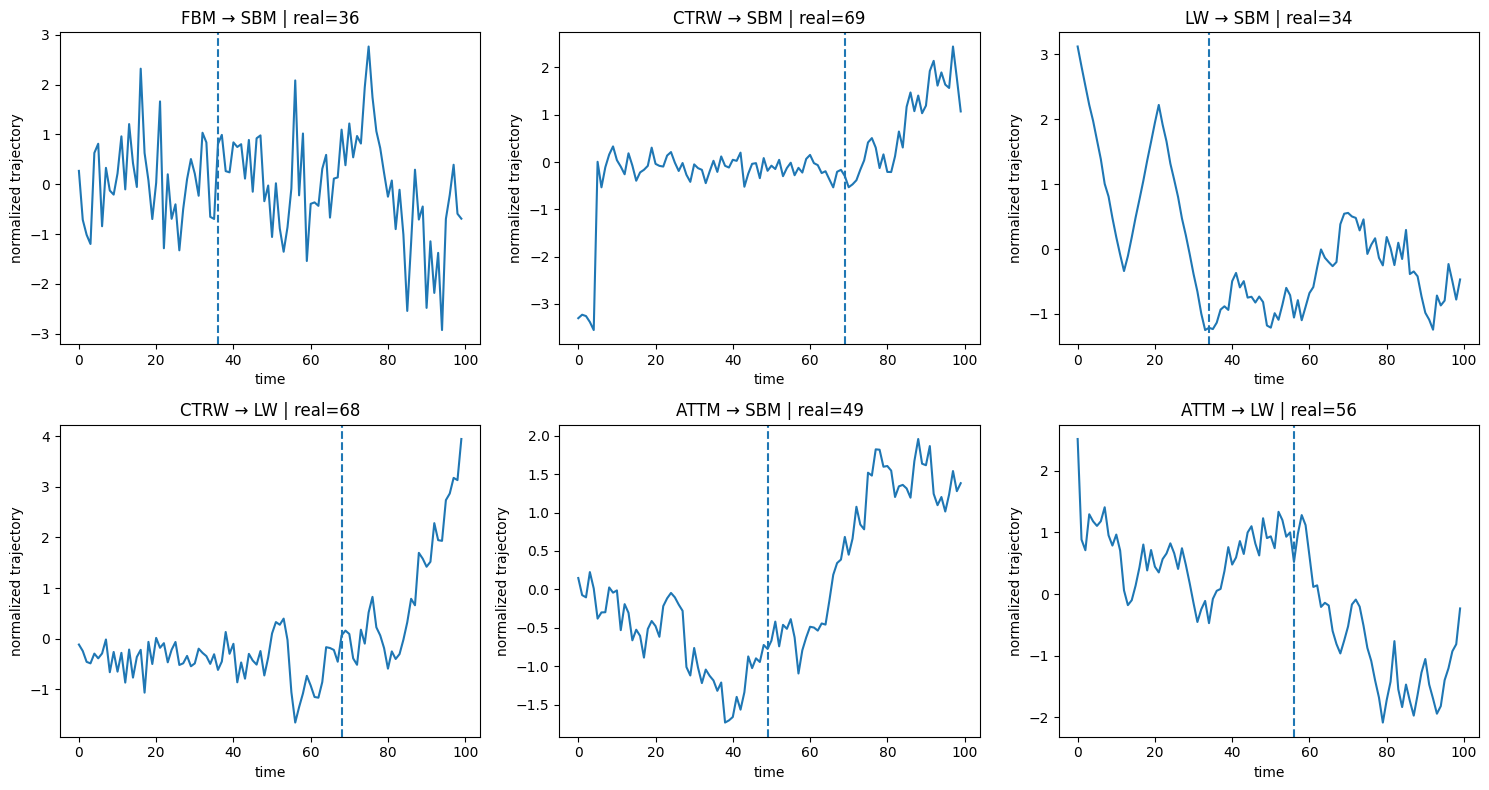

In [5]:
def plot_examples(x, positions, metadata, n_examples=6):
    n_examples = min(n_examples, len(x))
    selected = np.random.choice(len(x), size=n_examples, replace=False)
    columns = 3
    rows = int(np.ceil(n_examples / columns))

    plt.figure(figsize=(15, 4 * rows))

    for panel, index in enumerate(selected, start=1):
        plt.subplot(rows, columns, panel)
        plt.plot(x[index, :, 0])
        plt.axvline(int(positions[index]), linestyle="--")
        plt.title(f"{metadata.loc[index, 'transition']} | real={int(positions[index])}")
        plt.xlabel("time")
        plt.ylabel("normalized trajectory")

    plt.tight_layout()
    plt.show()


plot_examples(x_train, train_positions, train_metadata)

## 6. Construcción del modelo Transformer

El modelo Transformer convierte primero cada punto de la trayectoria en una representación latente. Después añade una codificación posicional aprendible para conservar la información del orden temporal.

A continuación, los bloques de auto-atención multi-cabeza permiten relacionar diferentes posiciones de la misma trayectoria. Esta estructura ayuda al modelo a identificar cambios entre el primer y el segundo segmento antes de producir la predicción final del punto de cambio.

In [6]:
@tf.keras.utils.register_keras_serializable()
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, model_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.model_dim = model_dim
        self.position_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=model_dim
        )

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        encoded_positions = self.position_embedding(positions)
        return inputs + encoded_positions

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "model_dim": self.model_dim
        })
        return config


def transformer_encoder_block(inputs, model_dim, num_heads, feedforward_dim, dropout_rate):
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=model_dim // num_heads,
        dropout=dropout_rate
    )(inputs, inputs)

    x = layers.Add()([inputs, attention_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    feedforward_output = layers.Dense(feedforward_dim, activation="relu")(x)
    feedforward_output = layers.Dropout(dropout_rate)(feedforward_output)
    feedforward_output = layers.Dense(model_dim)(feedforward_output)

    x = layers.Add()([x, feedforward_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    return x


def build_transformer_changepoint_model(
    input_shape,
    model_dim=64,
    num_heads=4,
    feedforward_dim=128,
    num_blocks=3,
    dropout_rate=0.20
):
    inputs = layers.Input(shape=input_shape)

    x = layers.Dense(model_dim)(inputs)
    x = PositionalEmbedding(input_shape[0], model_dim)(x)

    for _ in range(num_blocks):
        x = transformer_encoder_block(
            x,
            model_dim=model_dim,
            num_heads=num_heads,
            feedforward_dim=feedforward_dim,
            dropout_rate=dropout_rate
        )

    average_pooling = layers.GlobalAveragePooling1D()(x)
    max_pooling = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([average_pooling, max_pooling])

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.20)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="transformer_changepoint_regressor"
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=losses.Huber(delta=0.05),
        metrics=[metrics.MeanAbsoluteError(name="mae")]
    )

    return model


model = build_transformer_changepoint_model(input_shape=x_train.shape[1:])
model.summary()

Model: "transformer_changepoint_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 100, 64)           │             128 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ positional_embedding          │ (None, 100, 64)           │           6,400 │ dense[0][0]                │
│ (PositionalEmbedding)         │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 100, 64)           │          16,640 │ positional_embedding[0][0… │
│ (MultiHeadAttention)          │                           │                 │ positional_embedding[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 100, 64)           │               0 │ positional_embedding[0][0… │
│                               │                           │                 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 100, 64)           │             128 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 100, 128)          │           8,320 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 100, 128)          │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 100, 64)           │           8,256 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 100, 64)           │               0 │ layer_normalization[0][0], │
│                               │                           │                 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 100, 64)           │             128 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 100, 64)           │          16,640 │ layer_normalization_1[0][… │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_2 (Add)                   │ (None, 100, 64)           │               0 │ layer_normalization_1[0][… │
│                               │                           │                 │ multi_head_attention_1[0]… │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 115,265 (450.25 KB)

 Trainable params: 115,265 (450.25 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento

El entrenamiento se realizó con el mismo protocolo usado en las demás arquitecturas, manteniendo `FAST_RUN = False`. Se emplearon **200.000 trayectorias de entrenamiento**, **20.000 de validación** y **200.000 de prueba**.

El modelo se entrenó con un máximo de 80 épocas y un tamaño de lote de 256. Para mejorar el proceso se utilizó parada temprana, reducción de la tasa de aprendizaje cuando la validación dejaba de mejorar y guardado del mejor modelo para realizar después la evaluación final.

In [7]:
early_stop = callbacks.EarlyStopping(
    monitor="val_mae",
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

model_checkpoint = callbacks.ModelCheckpoint(
    OUTPUT_DIR / "best_transformer_changepoint.keras",
    monitor="val_mae",
    save_best_only=True
)

csv_logger = callbacks.CSVLogger(
    OUTPUT_DIR / "transformer_training_log.csv",
    append=True
)

backup = callbacks.BackupAndRestore(
    backup_dir=str(OUTPUT_DIR / "transformer_training_backup")
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop, reduce_lr, model_checkpoint, csv_logger, backup],
    verbose=1
)

Epoch 1/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1505s 2s/step - loss: 0.0064 - mae: 0.1510 - val_loss: 0.0060 - val_mae: 0.1443 - learning_rate: 0.0010
Epoch 2/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1236s 2s/step - loss: 0.0060 - mae: 0.1428 - val_loss: 0.0059 - val_mae: 0.1405 - learning_rate: 0.0010
Epoch 3/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 674s 860ms/step - loss: 0.0059 - mae: 0.1405 - val_loss: 0.0057 - val_mae: 0.1377 - learning_rate: 0.0010
Epoch 4/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 619s 791ms/step - loss: 0.0058 - mae: 0.1388 - val_loss: 0.0057 - val_mae: 0.1366 - learning_rate: 0.0010
Epoch 5/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 655s 837ms/step - loss: 0.0057 - mae: 0.1374 - val_loss: 0.0057 - val_mae: 0.1363 - learning_rate: 0.0010
Epoch 6/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 636s 814ms/step - loss: 0.0056 - mae: 0.1356 - val_loss: 0.0055 - val_mae: 0.1331 - learning_rate: 0.0010
Epoch 7/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 762s 916ms/step - loss: 0.0055 - mae: 0.1337 - val_loss: 0.0054 - val_mae: 0.1314 - lear

## 8. Evolución del entrenamiento

Se visualiza la pérdida y el error absoluto medio. El MAE se multiplica por la longitud de la trayectoria para interpretarlo directamente como error en puntos temporales.

,loss,mae,val_loss,val_mae,learning_rate
75,0.004560,0.113202,0.004641,0.114582,0.00001
76,0.004545,0.112887,0.004645,0.114666,0.00001
77,0.004549,0.112979,0.004645,0.114661,0.00001
78,0.004549,0.112981,0.004645,0.114669,0.00001
79,0.004548,0.112930,0.004645,0.114661,0.00001


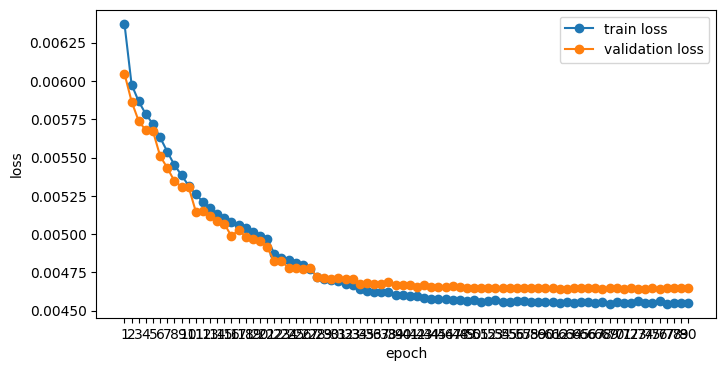

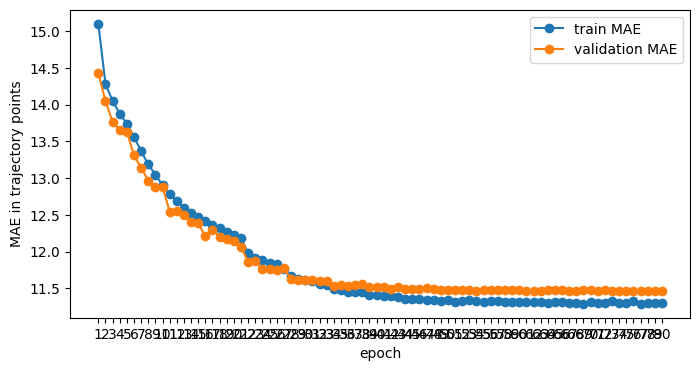

In [8]:
history_frame = pd.DataFrame(history.history)

display(history_frame.tail())

epochs_range = range(1, len(history_frame) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_frame["loss"], marker="o", label="train loss")
plt.plot(epochs_range, history_frame["val_loss"], marker="o", label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.xticks(epochs_range)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_frame["mae"] * LENGTH, marker="o", label="train MAE")
plt.plot(epochs_range, history_frame["val_mae"] * LENGTH, marker="o", label="validation MAE")
plt.xlabel("epoch")
plt.ylabel("MAE in trajectory points")
plt.xticks(epochs_range)
plt.legend()
plt.show()

## 9. Predicción y métricas globales

El modelo produce una posición normalizada. Después se multiplica por la longitud de la trayectoria para obtener la posición predicha en puntos temporales.

In [9]:
def predict_positions(model, x):
    predicted_normalized = model.predict(
        x,
        batch_size=PREDICT_BATCH_SIZE,
        verbose=0
    ).reshape(-1)

    predicted_positions = np.rint(predicted_normalized * LENGTH).astype(np.int32)
    predicted_positions = np.clip(
        predicted_positions,
        MIN_SEGMENT_LENGTH,
        LENGTH - MIN_SEGMENT_LENGTH
    )

    return predicted_positions, predicted_normalized


predicted_test_positions, predicted_test_normalized = predict_positions(model, x_test)

test_mae = mean_absolute_error(test_positions, predicted_test_positions)
test_rmse = np.sqrt(mean_squared_error(test_positions, predicted_test_positions))

global_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE"],
    "value_in_points": [test_mae, test_rmse]
})

global_metrics

,metric,value_in_points
0,MAE,11.411690
1,RMSE,15.186792


## 10. Resultados por transición ordenada

Se calculan las métricas para cada pareja `model1 → model2`. Esto permite identificar qué transiciones son más fáciles o más difíciles para el Transformer.

In [10]:
result_frame = test_metadata.copy().reset_index(drop=True)
result_frame["true_changepoint"] = test_positions
result_frame["predicted_changepoint"] = predicted_test_positions
result_frame["error"] = result_frame["predicted_changepoint"] - result_frame["true_changepoint"]
result_frame["absolute_error"] = result_frame["error"].abs()
result_frame["predicted_normalized"] = predicted_test_normalized

pair_metrics = (
    result_frame
    .groupby(["model1", "model2"])
    .agg(
        samples=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda values: float(np.sqrt(np.mean(np.square(values))))),
        median_absolute_error=("absolute_error", "median"),
        mean_bias=("error", "mean")
    )
    .reset_index()
    .sort_values("mae")
)

pair_metrics["transition"] = pair_metrics["model1"] + " → " + pair_metrics["model2"]
pair_metrics = pair_metrics[
    ["transition", "model1", "model2", "samples", "mae", "rmse", "median_absolute_error", "mean_bias"]
]

pair_metrics

,transition,model1,model2,samples,mae,rmse,median_absolute_error,mean_bias
6,CTRW → LW,CTRW,LW,10000,6.7944,10.134890,4.0,0.1926
13,LW → CTRW,LW,CTRW,10000,7.7835,11.160049,5.0,1.4515
5,CTRW → FBM,CTRW,FBM,10000,9.6121,13.501389,6.0,0.6863
2,ATTM → LW,ATTM,LW,10000,9.8485,13.634907,7.0,-0.3591
7,CTRW → SBM,CTRW,SBM,10000,10.1883,13.947018,7.0,1.7927
9,FBM → CTRW,FBM,CTRW,10000,10.2920,13.951136,7.0,0.1610
4,CTRW → ATTM,CTRW,ATTM,10000,10.5892,14.556985,7.0,1.1018
12,LW → ATTM,LW,ATTM,10000,10.7336,14.342099,8.0,2.8650
10,FBM → LW,FBM,LW,10000,10.8929,14.716627,8.0,-0.7311
14,LW → FBM,LW,FBM,10000,10.9626,14.904241,8.0,1.2796


## 11. Matriz de error por transición

La matriz resume el MAE para cada transición ordenada. Las filas corresponden al primer segmento y las columnas al segundo segmento.

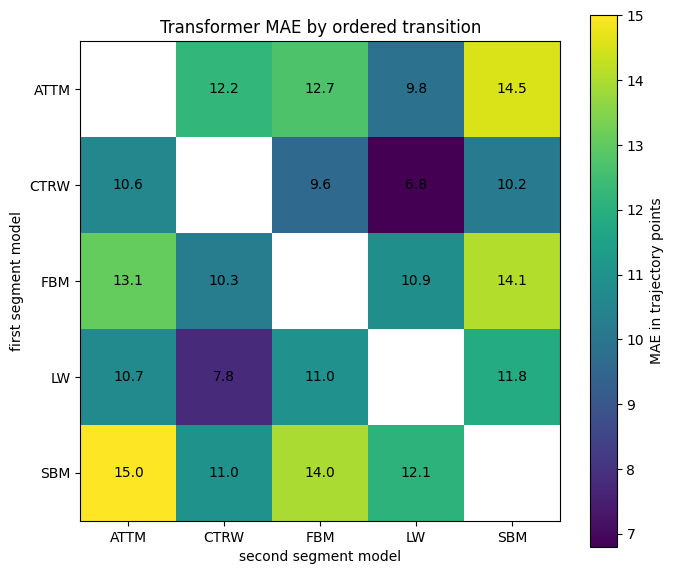

In [11]:
heatmap = pd.DataFrame(np.nan, index=MODELS, columns=MODELS)

for _, row in pair_metrics.iterrows():
    if row["model1"] in MODELS and row["model2"] in MODELS:
        heatmap.loc[row["model1"], row["model2"]] = row["mae"]

plt.figure(figsize=(7, 6))
plt.imshow(heatmap.values.astype(float))
plt.xticks(range(len(MODELS)), MODELS)
plt.yticks(range(len(MODELS)), MODELS)
plt.xlabel("second segment model")
plt.ylabel("first segment model")
plt.title("Transformer MAE by ordered transition")
plt.colorbar(label="MAE in trajectory points")

for i in range(len(MODELS)):
    for j in range(len(MODELS)):
        value = heatmap.iloc[i, j]
        if np.isfinite(value):
            plt.text(j, i, f"{value:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 12. Panel de trayectorias por transición

Se muestra una trayectoria representativa para cada transición ordenada. La línea discontinua indica el punto real y la línea continua indica la predicción del modelo.

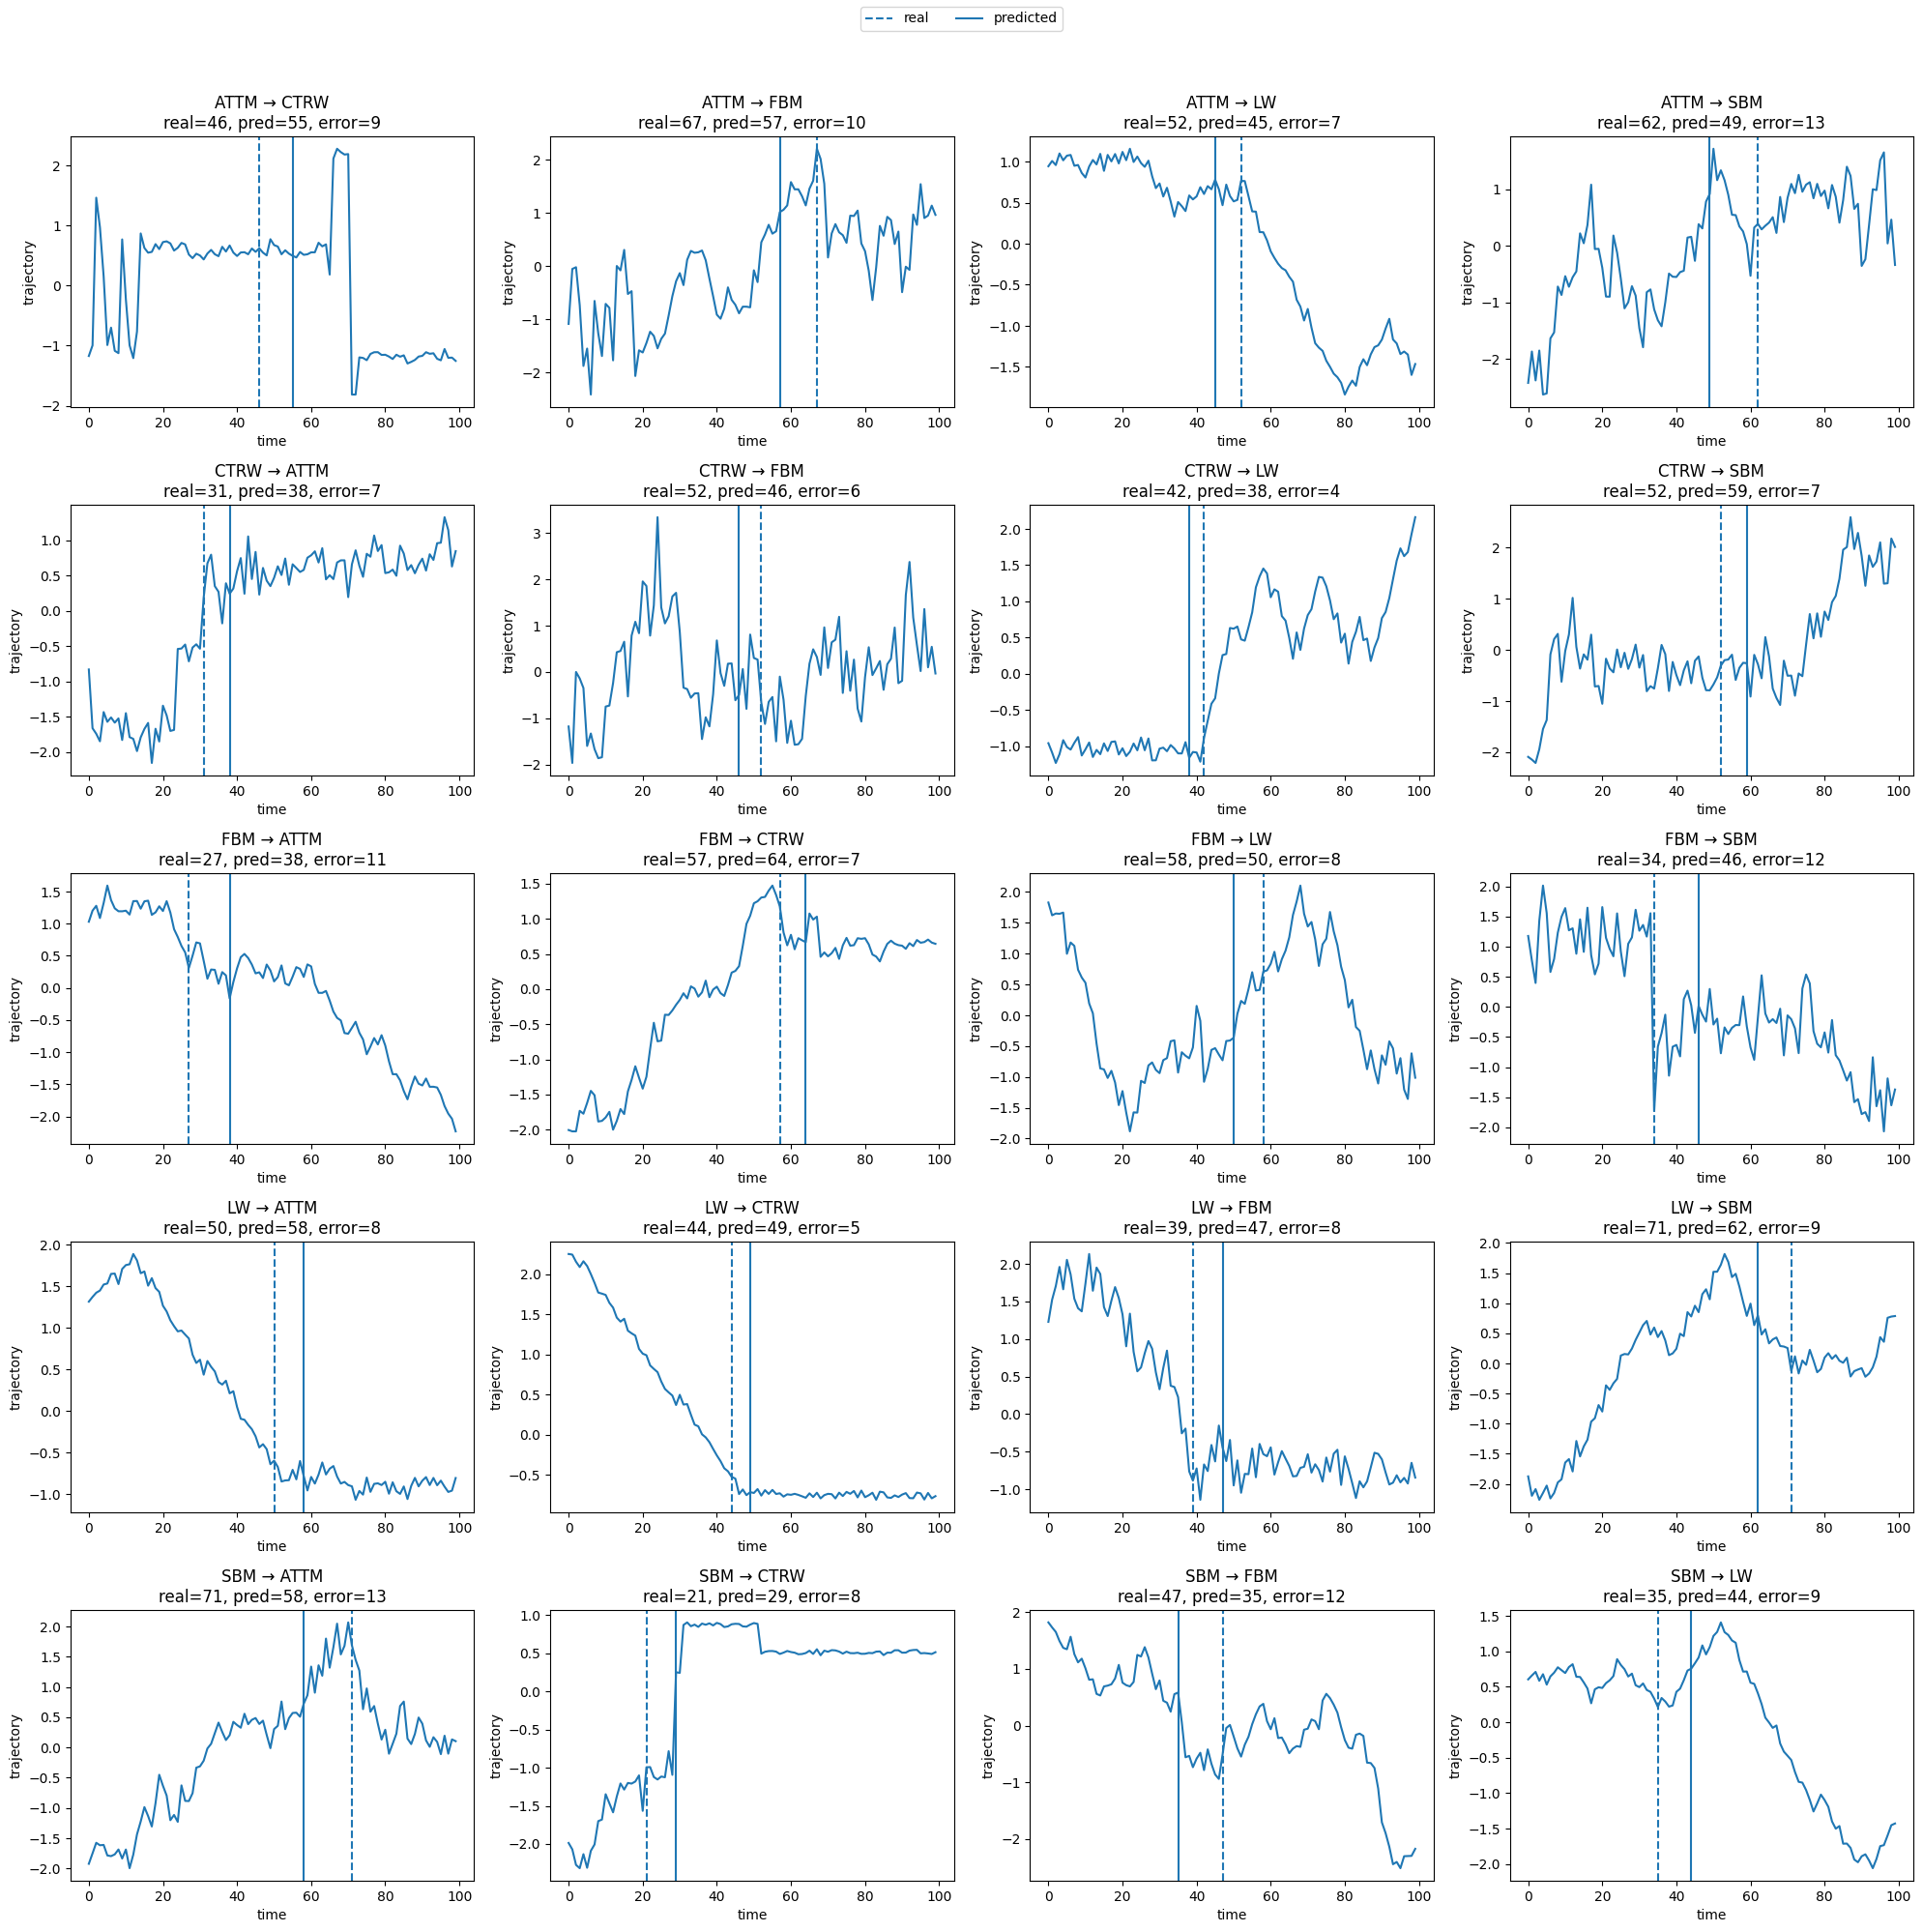

In [12]:
def representative_index_for_pair(frame, model1, model2):
    candidates = frame[(frame["model1"] == model1) & (frame["model2"] == model2)]

    if candidates.empty:
        return None

    target_error = candidates["absolute_error"].median()
    distances = (candidates["absolute_error"] - target_error).abs()

    return int(distances.idxmin())


def plot_transition_panel(x, results, max_pairs=20):
    selected_pairs = TRANSITIONS[:max_pairs]
    columns = 4
    rows = int(np.ceil(len(selected_pairs) / columns))

    plt.figure(figsize=(20, 4 * rows))

    for panel, (model1, model2) in enumerate(selected_pairs, start=1):
        index = representative_index_for_pair(results, model1, model2)
        plt.subplot(rows, columns, panel)

        if index is None:
            plt.title(f"{model1} → {model2}\nno data")
            plt.axis("off")
            continue

        values = x[index, :, 0]
        real_position = int(results.loc[index, "true_changepoint"])
        predicted_position = int(results.loc[index, "predicted_changepoint"])
        absolute_error = float(results.loc[index, "absolute_error"])

        plt.plot(values)
        plt.axvline(real_position, linestyle="--", label="real")
        plt.axvline(predicted_position, linestyle="-", label="predicted")

        plt.title(
            f"{model1} → {model2}\n"
            f"real={real_position}, pred={predicted_position}, error={absolute_error:.0f}"
        )

        plt.xlabel("time")
        plt.ylabel("trajectory")

    handles, labels = plt.gca().get_legend_handles_labels()

    if handles:
        plt.figlegend(handles, labels, loc="upper center", ncol=2)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_transition_panel(x_test, result_frame)

## 13. Guardado de resultados

Se guardan las métricas, las predicciones y el modelo entrenado para poder analizarlos posteriormente.

In [13]:
global_metrics.to_csv(OUTPUT_DIR / "transformer_global_metrics.csv", index=False)
pair_metrics.to_csv(OUTPUT_DIR / "transformer_pair_metrics.csv", index=False)
result_frame.to_csv(OUTPUT_DIR / "transformer_test_predictions.csv", index=False)
model.save(OUTPUT_DIR / "transformer_changepoint_final.keras")

print(f"Results saved in: {OUTPUT_DIR.resolve()}")

Results saved in: C:\Users\chair\OneDrive\Bureau\transformer_results_final


## 14. Conclusión

El modelo Transformer fue aplicado a trayectorias sintéticas de longitud **L = 100**, formadas por dos fragmentos con dinámicas de difusión diferentes. Su objetivo fue estimar la posición temporal donde se produce el cambio entre ambos segmentos.

La ejecución final se hizo con `FAST_RUN = False`, usando **200.000 trayectorias para entrenamiento**, **20.000 para validación** y **200.000 para prueba**. El conjunto de test está equilibrado, con **10.000 trayectorias por cada una de las 20 transiciones ordenadas**.

En el conjunto de prueba, el modelo obtuvo un **MAE = 11.41** y un **RMSE = 15.19** puntos temporales. Esto significa que la predicción del Transformer se desvía, en promedio, alrededor de once posiciones respecto al punto real de cambio.

El análisis por transición muestra que el comportamiento no es uniforme. Las parejas **CTRW → LW** y **LW → CTRW** presentan los errores más bajos, mientras que transiciones como **SBM → ATTM**, **ATTM → SBM**, **FBM → SBM** y **SBM → FBM** resultan más difíciles para el modelo.